import packages

In [1]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
from collections import defaultdict
import escher
from escher import Builder
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import re
from re import match
import numpy as np

workflow

load dataset -> check the data information (metabolites name) -> setup the control environment -> calculate each analyse (growth rate)

load dataset and set the save path

In [2]:
# State the path to the file.xml
sbml_fname = 'S_meliloti_1348.xml'
# Read the model
model = read_sbml_model(sbml_fname)
reference = "==="
# Create save folder
save_path = f"Results_{sbml_fname.replace('.xml','')}"
os.makedirs(save_path, exist_ok=True)

print("Model ID:", model.id)
print("Model Name:", model.name)
print("Metabolites:", len(model.metabolites))
print("Reactions:", len(model.reactions))
print("Genes:", len(model.genes))
print("Current objective:", model.objective)

# Show first 10 genes
for gene in list(model.genes)[:10]:
    print("ID:", gene.id)
    print("Name:", gene.name)
    print()

Model ID: iGD1348
Model Name: Sinorhizobium_meliloti_1021
Metabolites: 1160
Reactions: 1407
Genes: 1351
Current objective: Maximize
1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5
ID: g1
Name: COBRAProtein1

ID: g2
Name: COBRAProtein2

ID: g3
Name: COBRAProtein3

ID: g4
Name: COBRAProtein4

ID: g5
Name: COBRAProtein5

ID: g6
Name: COBRAProtein6

ID: g7
Name: COBRAProtein7

ID: g8
Name: COBRAProtein8

ID: g9
Name: COBRAProtein9

ID: g10
Name: COBRAProtein10



In [3]:
model

Name,iGD1348
Memory address,1d2042b17f0
Number of metabolites,1160
Number of reactions,1407
Number of genes,1351
Number of groups,0
Objective expression,1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5
Compartments,"Cytoplasm, Extracellular"


In [4]:
model.medium

{'EX_cpd00001_e0': 1000.0,
 'EX_cpd00067_e0': 1000.0,
 'EX_cpd00011_e0': 1000.0,
 'EX_cpd00204_e0': 1000.0,
 'EX_cpd00007_e0': 1000.0,
 'EX_cpd00149_e0': 1000.0,
 'EX_cpd00009_e0': 1000.0,
 'EX_cpd00254_e0': 1000.0,
 'EX_cpd00063_e0': 1000.0,
 'EX_cpd00030_e0': 1000.0,
 'EX_cpd10515_e0': 1000.0,
 'EX_cpd10516_e0': 1000.0,
 'EX_cpd00034_e0': 1000.0,
 'EX_cpd00205_e0': 1000.0,
 'EX_cpd00971_e0': 1000.0,
 'EX_cpd00104_e0': 1000.0,
 'EX_cpd00013_e0': 1000.0,
 'EX_cpd00048_e0': 1000.0,
 'EX_cpd00076_e0': 1000.0,
 'EX_cpd00027_e0': 1000.0,
 'EX_cpd00036_e0': 1000.0,
 'EX_cpd00851_e0': 1000.0,
 'EX_cpd02175_e0': 1000.0,
 'EX_cpd00224_e0': 1000.0,
 'EX_cpd00567_e0': 1000.0,
 'EX_cpd00129_e0': 1000.0,
 'EX_cpd00064_e0': 1000.0,
 'EX_cpd00130_e0': 1000.0,
 'EX_cpd00106_e0': 1000.0,
 'EX_cpd00197_e0': 1000.0,
 'EX_cpd00392_e0': 1000.0,
 'EX_cpd00366_e0': 1000.0,
 'EX_cpd00417_e0': 1000.0,
 'EX_cpd00108_e0': 1000.0,
 'EX_cpd00119_e0': 1000.0,
 'EX_cpd00107_e0': 1000.0,
 'EX_cpd00156_e0': 1000.0,
 

In [5]:
print(model.summary())
[r for r in model.reactions if r.objective_coefficient == 1]

Objective
1.0 rxnBIOMASS = 89.9129870230999

Uptake
------
  Metabolite       Reaction      Flux  C-Number C-Flux
cpd00007[e0] EX_cpd00007_e0     107.4         0  0.00%
cpd00009[e0] EX_cpd00009_e0  0.001798         0  0.00%
cpd00030[e0] EX_cpd00030_e0 0.0008991         0  0.00%
cpd00034[e0] EX_cpd00034_e0 0.0008991         0  0.00%
cpd00039[e0] EX_cpd00039_e0     15.89         6  1.01%
cpd00051[e0] EX_cpd00051_e0     124.7         6  7.95%
cpd00060[e0] EX_cpd00060_e0     12.06         5  0.64%
cpd00063[e0] EX_cpd00063_e0 0.0008991         0  0.00%
cpd00067[e0] EX_cpd00067_e0      1000         0  0.00%
cpd00069[e0] EX_cpd00069_e0     11.36         9  1.09%
cpd00080[e0] EX_cpd00080_e0     54.15         3  1.73%
cpd00084[e0] EX_cpd00084_e0     115.5         3  3.68%
cpd00098[e0] EX_cpd00098_e0     14.12         5  0.75%
cpd00104[e0] EX_cpd00104_e0  0.001798        10  0.00%
cpd00129[e0] EX_cpd00129_e0      70.3         5  3.73%
cpd00149[e0] EX_cpd00149_e0  0.001798         0  0.00%
cpd001

[<Reaction rxnBIOMASS at 0x1d204abdde0>]

to see the metabolites name or id name

In [6]:
model.metabolites.get_by_id('cpd00007[e0]').name

'O2_e0'

In [7]:
matches = [m for m in model.metabolites if 'h2o' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

cpd00001[c0] H2O_c0
cpd00001[e0] H2O_e0
cpd00025[c0] H2O2_c0


rename

exchanges reaction

In [8]:
exchange_rows = []
with open(os.path.join(save_path, "boundary_list.txt"), "w") as f:
    header = f"{'exchange_id':30s} | {'reaction_name':35s} | {'lower_bound':12s} | {'upper_bound'}"
    f.write(header + "\n" + "-"*95 + "\n")
    for r in model.boundary:
        line = f"{r.id:30s} | {r.name}"
        f.write(line + "\n")
        exchange_rows.append({"exchange_id": r.id, "reaction_name": r.name,
                     "lower_bound": r.lower_bound, "upper_bound": r.upper_bound})
        
boundary_df = pd.DataFrame(exchange_rows)

csv_file = os.path.join(save_path, "boundary_reactions.csv")
tsv_file = os.path.join(save_path, "boundary_reactions.tsv")

boundary_df.to_csv(csv_file, index=False)
boundary_df.to_csv(tsv_file, sep='\t', index=False)

print(f"Successfully saved {len(boundary_df)} boundary reactions to {save_path}")

# check nitrogen fixation reaction
nif_rxns = ["rxn06874_c0", "rxnNifS_c0", "rxnNifU", "symbiosis_c0",
            "EX_cpd00528_e0", "EX_cpdFixed_e0"]
print("\nNitrogen fixation reactions:")
for rid in nif_rxns:
    try:
        r = model.reactions.get_by_id(rid)
        print(f"{rid:30s} | {r.name}")
    except KeyError:
        print(f"{rid} — NOT FOUND")


Successfully saved 179 boundary reactions to Results_S_meliloti_1348

Nitrogen fixation reactions:
rxn06874_c0                    | nitrogenase
rxnNifS_c0                     | sulphur atom for Fe–S cluster biogenesis
rxnNifU                        | Iron sulfur cluster assembly
symbiosis_c0                   | Nitrogen fixing symbiosis reaction
EX_cpd00528_e0                 | EX N2 gas e0
EX_cpdFixed_e0                 | Fixed ammonia e0


In [9]:
model.metabolites

[<Metabolite cpd00001[c0] at 0x1d2042b2660>,
 <Metabolite cpd00001[e0] at 0x1d20426e710>,
 <Metabolite cpd00002[c0] at 0x1d20426e5d0>,
 <Metabolite cpd00003[c0] at 0x1d204267360>,
 <Metabolite cpd00004[c0] at 0x1d204266d70>,
 <Metabolite cpd00005[c0] at 0x1d2041f71d0>,
 <Metabolite cpd00006[c0] at 0x1d2042f0380>,
 <Metabolite cpd00007[c0] at 0x1d1daca3790>,
 <Metabolite cpd00007[e0] at 0x1d203c89f50>,
 <Metabolite cpd00008[c0] at 0x1d203c89e50>,
 <Metabolite cpd00009[c0] at 0x1d203f57020>,
 <Metabolite cpd00009[e0] at 0x1d1dac3f3e0>,
 <Metabolite cpd00010[c0] at 0x1d204283230>,
 <Metabolite cpd00011[c0] at 0x1d204283150>,
 <Metabolite cpd00011[e0] at 0x1d20434d090>,
 <Metabolite cpd00012[c0] at 0x1d20428db50>,
 <Metabolite cpd00012[e0] at 0x1d20428d910>,
 <Metabolite cpd00013[c0] at 0x1d1dac84520>,
 <Metabolite cpd00013[e0] at 0x1d1dac84aa0>,
 <Metabolite cpd00014[c0] at 0x1d204354050>,
 <Metabolite cpd00015[c0] at 0x1d204333f70>,
 <Metabolite cpd00016[c0] at 0x1d2043540f0>,
 <Metaboli

In [10]:
# Reaction List
r_data = []
for r in model.reactions:
    r_data.append({
        "current_id": r.id,
        "name": r.name,
        "reaction_string": r.build_reaction_string(),
        "subsystem": r.subsystem,
        "lower_bound": r.lower_bound,
        "upper_bound": r.upper_bound,
        "suggested_new_id": ""  
    })

# Metabolite List
met_data = []
for m in model.metabolites:
    met_data.append({
        "current_id": m.id,
        "name": m.name,
        "formula": m.formula,
        "compartment": m.compartment,
        "charge": m.charge,
        "suggested_new_id": ""  # Fill this in Excel for renaming
    })

# Convert to DataFrames
df_r = pd.DataFrame(r_data)
df_mets = pd.DataFrame(met_data)
r_file = os.path.join(save_path,f"{sbml_fname.replace('.xml','')}_reactions_for_mapping.csv")
met_file = os.path.join(save_path,f"{sbml_fname.replace('.xml','')}_metabolites_for_mapping.csv")
df_r.to_csv(r_file, index=False)
df_mets.to_csv(met_file, index=False)

print(f"Exported {len(df_r)} reactions and {len(df_mets)} metabolites to your files.")

Exported 1407 reactions and 1160 metabolites to your files.


fine biomass

In [11]:
biomass_candidates = [r.id for r in model.reactions if "biomass" in r.id.lower()]

if not biomass_candidates:
    raise ValueError("No biomass reaction found!")

biomass_rxn = biomass_candidates[0]
print("\nUsing biomass reaction:", biomass_rxn)

model.objective = biomass_rxn


Using biomass reaction: rxnBIOMASS


from the 752 workshop week 7 copy the model

In [12]:
model_bulk = model.copy()
print("Objective bulk soil:", model_bulk.objective)
model_rh = model.copy()
print("Objective rhizoshere:", model_rh.objective)
model_no = model.copy()
print("Objective nodule:", model_no.objective)

Objective bulk soil: Maximize
1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5
Objective rhizoshere: Maximize
1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5
Objective nodule: Maximize
1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5


set the environment control

soil environment from https://doi.org/10.1038/ncomms12219

table https://static-content.springer.com/esm/art%3A10.1038%2Fncomms12219/MediaObjects/41467_2016_BFncomms12219_MOESM588_ESM.pdf 

To set the start control for all the sample as the same environment 

setup the code or name in each metabolites depend on each sample


bulk soil environment

In [13]:
for r in model_bulk.exchanges:
    r.lower_bound=0

# bulk soil 60 
exchange_bounds_bulk = {
    'EX_cpd00224_e0': -0.28889705,    #L-arabinose
    'EX_cpd00108_e0': -0.25290619,    #D-galactose 
    'EX_cpd00027_e0': -0.61972444,    #D-glucose 
    'EX_cpd00138_e0': -0.2540567,     #D-mannose 
    'EX_cpd00396_e0': -0.13913636,    #L-rhamnose 
    'EX_cpd00154_e0': -0.21280795,    #Xylose
    'EX_cpd00105_e0': -0.01862144,    #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -0.0056245,     #Succinate
    'EX_cpd00130_e0': -0.03649016,    #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': -0.0068175,     #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': 0,              #L-glutamate 
    'EX_cpd00129_e0': -0.01102953,    #L-proline 
    'EX_cpd00033_e0': -0.0068175,     #Glycine 
    'EX_cpd00035_e0': -0.02780553,    #L-alanine
    'EX_cpd00156_e0': -0.02928849,    #L-valine 
    'EX_cpd00084_e0': -0.0068175,     #L-cysteine 
    'EX_cpd00322_e0': -0.0199273,     #L-isoleucine 
    'EX_cpd00107_e0': -0.03596182,    #L-leucine 
    'EX_cpd00069_e0': -0.0068175,     #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.0068175,     #L-ornithine 
    'EX_cpd00119_e0': -0.0068175,     #L-histidine 
    'EX_cpd00051_e0': -0.0068175,     #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': 0,              #Cob(I)alamin
    'EX_cpd00919_e0': 0,              #Homocitrate
    'EX_cpd11574_e0': 0,              #Molybdate
    'EX_cpd00305_e0': 0,              #Thiamine
    'EX_cpd00121_e0': 0,              #M-inositol 
    'EX_cpd00528_e0': 0,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds:")
for comp_id, bound in exchange_bounds_bulk.items():
    if comp_id in model_bulk.reactions:
        model_bulk.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")


Setting exchange bounds:


rhizoshere environment

In [14]:
for r in model_rh.exchanges:
    r.lower_bound=0

# rhizoshere soil 60 
exchange_bounds_rh = {
    'EX_cpd00224_e0': -0.26974143,    #L-arabinose
    'EX_cpd00108_e0': -0.18317325,    #D-galactose 
    'EX_cpd00027_e0': -0.04098397,    #D-glucose 
    'EX_cpd00138_e0': -0.05436649,    #D-mannose 
    'EX_cpd00396_e0': -0.02927426,    #L-rhamnose 
    'EX_cpd00154_e0': -0.04600242,    #Xylose
    'EX_cpd00105_e0': 0,              #D-ribose
    'EX_cpd00076_e0': -0.02049199,    #Sucrose
    'EX_cpd00382_e0': -0.01024599,    #D-raffinose 
    'EX_cpd01133_e0': -0.03073798,    #Stachyose
    'EX_cpd00036_e0': -0.12240603,    #Succinate
    'EX_cpd00130_e0': -0.79413596,    #L-malate 
    'EX_cpd00041_e0': -0.03205557,    #L-aspartate 
    'EX_cpd00161_e0': -0.00961667,    #L-threonine 
    'EX_cpd00054_e0': -0.01004986,    #L-serine
    'EX_cpd00023_e0': -0.0283302,     #L-glutamate 
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': -0.00693094,    #Glycine 
    'EX_cpd00035_e0': -0.00823049,    #L-alanine
    'EX_cpd00156_e0': -0.00337883,    #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': -0.00186269,    #L-isoleucine 
    'EX_cpd00107_e0': -0.00303228,    #L-leucine 
    'EX_cpd00069_e0': -0.00233919,    #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.00831712,    #L-ornithine 
    'EX_cpd00119_e0': -0.00506825,    #L-histidine 
    'EX_cpd00051_e0': -0.00948672,    #L-arginine 
    'EX_cpd00851_e0': -0.26974144,    #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': 0,              #Cob(I)alamin
    'EX_cpd00919_e0': 0,              #Homocitrate
    'EX_cpd11574_e0': 0,              #Molybdate
    'EX_cpd00305_e0': 0,              #Thiamine
    'EX_cpd00121_e0': 0,              #M-inositol 
    'EX_cpd00528_e0': 0,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds rhizosphere:")
for comp_id, bound in exchange_bounds_rh.items():
    if comp_id in model_rh.reactions:
        model_rh.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds rhizosphere:


nodule environment

In [15]:
for r in model_no.exchanges:
    r.lower_bound=0

# nodule soil 60 
exchange_bounds_no = {
    'EX_cpd00224_e0': 0,              #L-arabinose
    'EX_cpd00108_e0': 0,              #D-galactose 
    'EX_cpd00027_e0': 0,              #D-glucose 
    'EX_cpd00138_e0': 0.,             #D-mannose 
    'EX_cpd00396_e0': 0.,             #L-rhamnose 
    'EX_cpd00154_e0': 0.,             #Xylose
    'EX_cpd00105_e0': 0.,             #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -1.326,         #Succinate
    'EX_cpd00130_e0': -1.1122,        #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': 0,              #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': -2,             #L-glutamate 
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': 0.,             #Glycine 
    'EX_cpd00035_e0': 0.,             #L-alanine
    'EX_cpd00156_e0': 0.,             #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': 0,              #L-isoleucine 
    'EX_cpd00107_e0': 0,              #L-leucine 
    'EX_cpd00069_e0': 0,              #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': 0,              #L-ornithine 
    'EX_cpd00119_e0': 0,              #L-histidine 
    'EX_cpd00051_e0': 0,              #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': 0,              #Ammonia 
    'EX_cpd00209_e0': 0,              #Nitrate
    'EX_cpd00048_e0': -1000,          #Sulfate
    'EX_cpd00009_e0': -1000,          #Phosphate
    'EX_cpd00001_e0': -1000,          #H2O
    'EX_cpd00007_e0': -1.26,          #O2
    'EX_cpd00011_e0': -1000,          #CO2
    'EX_cpd00030_e0': 0,              #Mn2
    'EX_cpd00034_e0': 0,              #Zn2
    'EX_cpd00058_e0': 0,              #Cu2
    'EX_cpd00063_e0': 0,              #Ca2
    'EX_cpd00067_e0': -1000,          #H+  
    'EX_cpd00099_e0': 0,              #Cl- 
    'EX_cpd00104_e0': 0,              #Biotin
    'EX_cpd00149_e0': 0,              #Co2
    'EX_cpd00205_e0': 0,              #K+
    'EX_cpd00254_e0': -1000,          #Mg2+
    'EX_cpd00971_e0': 0,              #Na+
    'EX_cpd10515_e0': -1000,          #Fe2+ 
    'EX_cpd10516_e0': 0,              #Fe3+
    'EX_cpd00635_e0': -1000,          #Cob(I)alamin
    'EX_cpd00919_e0': -1000,          #Homocitrate
    'EX_cpd11574_e0': -1000,          #Molybdate
    'EX_cpd00305_e0': -1000,          #Thiamine
    'EX_cpd00121_e0': -0.01,          #M-inositol 
    'EX_cpd00528_e0': -1000,          #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds nodule:")
for comp_id, bound in exchange_bounds_no.items():
    if comp_id in model_no.reactions:
        model_no.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds nodule:


calculate

In [16]:
solution_bulk = model_bulk.optimize()

In [17]:
solution_rh = model_rh.optimize()

In [18]:
solution_no = model_no.optimize()

In [19]:
for name, sol in [("Bulk soil", solution_bulk), ("Rhizosphere", solution_rh), ("Nodule", solution_no)]:
    gr = sol.objective_value if sol.status == "optimal" else "INFEASIBLE"
    print(f"  {name:12s} | status: {sol.status:8s} | growth rate: {gr}")

  Bulk soil    | status: optimal  | growth rate: 0.20813413332345485
  Rhizosphere  | status: optimal  | growth rate: 0.16463868010851865
  Nodule       | status: optimal  | growth rate: 0.0


save data

growth rate summary

In [20]:
summary_rows = []
for cond_name, sol in [( "Bulk", solution_bulk),
                       ("Rhizosphere", solution_rh),
                       ("Nodule", solution_no)]:
    
    if sol.status == "optimal":
        gr      = sol.objective_value
        nif     = sol.fluxes.get("rxn06874_c0",   0.0)   # nitrogenase
        n2_up   = sol.fluxes.get("EX_cpd00528_e0",0.0)   # N2 uptake
        nh3_ex  = sol.fluxes.get("EX_cpd00013_e0",0.0)   # NH3 exchange
        fixed   = sol.fluxes.get("EX_cpdFixed_e0",0.0)   # fixed NH3 export
        o2_up   = sol.fluxes.get("EX_cpd00007_e0",0.0)   # O2 uptake
        doublt  = round(0.693147 / gr, 4) if gr > 0 else None
    else:
        gr = nif = n2_up = nh3_ex = fixed = o2_up = doublt = None

    summary_rows.append({
        "Species":              "S. meliloti",
        "Condition":            cond_name,
        "Status":               sol.status,
        "Growth_rate_h":        round(gr,    6) if gr    is not None else None,
        "Doubling_time_h":      doublt,
        "Nitrogenase_flux":     round(nif,   6) if nif   is not None else None,
        "N2_uptake":            round(abs(n2_up), 6),
        "NH3_exchange":         round(nh3_ex,6),
        "FixedNH3_export":      round(fixed, 6),
        "O2_uptake":            round(abs(o2_up), 6),
        "Reference":            reference,
    })

summary_df = pd.DataFrame(summary_rows)

# Save
summary_file = os.path.join(save_path, "growth_rate_summary.tsv")
summary_df.to_csv(summary_file, sep="\t", index=False)

print(summary_df.to_string(index=False))
print(f"\nSaved {summary_file}")


    Species   Condition  Status  Growth_rate_h  Doubling_time_h  Nitrogenase_flux  N2_uptake  NH3_exchange  FixedNH3_export  O2_uptake Reference
S. meliloti        Bulk optimal       0.208134           3.3303               0.0        0.0     -1.746121              0.0   1.582954       ===
S. meliloti Rhizosphere optimal       0.164639           4.2101               0.0        0.0     -1.105607              0.0   1.543468       ===
S. meliloti      Nodule optimal       0.000000              NaN               0.0        0.0      0.000000              0.0   1.260000       ===

Saved Results_S_meliloti_1348\growth_rate_summary.tsv


full flux tables 

In [21]:
# Save complete flux table for each condition
for cond_name, sol, model_cond in [
        ("bulk",        solution_bulk, model_bulk),
        ("rhizosphere", solution_rh,   model_rh),
        ("nodule",      solution_no,   model_no),
]:
    if sol.status != "optimal":
        print(f"  {cond_name}: skipped (infeasible)")
        continue

    flux_df = sol.to_frame().reset_index()
    flux_df.columns = ["reaction_id", "flux", "reduced_cost"]

    # Add readable reaction name
    flux_df["reaction_name"] = flux_df["reaction_id"].apply(
        lambda rid: model_cond.reactions.get_by_id(rid).name
        if rid in model_cond.reactions else ""
    )

    # Add condition column
    flux_df.insert(0, "condition", cond_name)

    # Save
    fname = os.path.join(save_path, f"{cond_name}_fluxes.tsv")
    flux_df.to_csv(fname, sep="\t", index=False)
    print(f"  Saved {len(flux_df)} reactions  {fname}")


  Saved 1407 reactions  Results_S_meliloti_1348\bulk_fluxes.tsv
  Saved 1407 reactions  Results_S_meliloti_1348\rhizosphere_fluxes.tsv
  Saved 1407 reactions  Results_S_meliloti_1348\nodule_fluxes.tsv


exchanges fluxes

In [22]:
exchange_rows = []

for cond_name, sol, model_cond in [
        ("Bulk",        solution_bulk, model_bulk),
        ("Rhizosphere", solution_rh,   model_rh),
        ("Nodule",      solution_no,   model_no),
]:
    if sol.status != "optimal":
        continue

    for rxn in model_cond.exchanges:
        flux = sol.fluxes.get(rxn.id, 0.0)
        if abs(flux) > 1e-9:          # only active exchanges
            exchange_rows.append({
                "condition":     cond_name,
                "reaction_id":   rxn.id,
                "reaction_name": rxn.name,
                "flux":          round(flux, 8),
                "direction":     "uptake" if flux < 0 else "secretion",
            })

ex_df = pd.DataFrame(exchange_rows)
ex_file = os.path.join(save_path, "exchange_fluxes_all_conditions.tsv")
ex_df.to_csv(ex_file, sep="\t", index=False)

print(f"Saved {len(ex_df)} active exchange fluxes  {ex_file}")
print()
# Show top 5 per condition
for cond in ["Bulk", "Rhizosphere", "Nodule"]:
    sub = ex_df[ex_df.condition == cond].sort_values("flux", key=abs, ascending=False).head(5)
    print(f"  {cond} — top 5 active exchanges:")
    print(sub[["reaction_name","flux","direction"]].to_string(index=False))
    print()


Saved 90 active exchange fluxes  Results_S_meliloti_1348\exchange_fluxes_all_conditions.tsv

  Bulk — top 5 active exchanges:
             reaction_name      flux direction
         EX H2O (water) e0 10.273990 secretion
EX CO2 (carbon dioxide) e0  2.330110 secretion
          EX H (proton) e0 -1.954946    uptake
       EX NH3 (ammonia) e0 -1.746121    uptake
         EX O2 (oxygen) e0 -1.582954    uptake

  Rhizosphere — top 5 active exchanges:
             reaction_name      flux direction
         EX H2O (water) e0  7.828201 secretion
          EX H (proton) e0 -3.652628    uptake
EX CO2 (carbon dioxide) e0  3.143372 secretion
         EX O2 (oxygen) e0 -1.543468    uptake
       EX NH3 (ammonia) e0 -1.105607    uptake

  Nodule — top 5 active exchanges:
             reaction_name      flux direction
EX CO2 (carbon dioxide) e0  2.075543 secretion
         EX H2O (water) e0  1.556657 secretion
         EX O2 (oxygen) e0 -1.260000    uptake
            EX L-malate e0 -1.112200    uptak

gene lists

In [23]:
# Save gene list for each condition model
for cond_name, model_cond in [
        ("bulk",        model_bulk),
        ("rhizosphere", model_rh),
        ("nodule",      model_no),
]:
    gene_data = [{
        "gene_id":       g.id,
        "gene_name":     g.name,
        "n_reactions":   len(g.reactions),
        "reaction_ids":  ";".join(r.id for r in g.reactions),
    } for g in model_cond.genes]

    gene_file = os.path.join(save_path, f"{cond_name}_genes.tsv")
    pd.DataFrame(gene_data).to_csv(gene_file, sep="\t", index=False)
    print(f"  Saved {len(gene_data)} genes  {gene_file}")


  Saved 1351 genes  Results_S_meliloti_1348\bulk_genes.tsv
  Saved 1351 genes  Results_S_meliloti_1348\rhizosphere_genes.tsv
  Saved 1351 genes  Results_S_meliloti_1348\nodule_genes.tsv


biomass over time 

In [24]:
# X(t) = X0 * exp(µ * t)
X0      = 0.01                          # inoculum g/L
t_hours = np.arange(0, 73, 1)          # 0 to 72 hours

time_rows = []
for cond_name, sol in [("Bulk",        solution_bulk),
                        ("Rhizosphere", solution_rh),
                        ("Nodule",      solution_no)]:

    mu = sol.objective_value if sol.status == "optimal" else 0.0
    for t in t_hours:
        time_rows.append({
            "species":    "S. meliloti",
            "condition":  cond_name,
            "time_h":     t,
            "mu":         round(mu, 6),
            "biomass_gL": round(X0 * np.exp(mu * t), 8),
        })

time_df = pd.DataFrame(time_rows)
time_file = os.path.join(save_path, "biomass_over_time.tsv")
time_df.to_csv(time_file, sep="\t", index=False)
print(f"Saved {len(time_df)} rows → {time_file}")

# Show biomass at key timepoints
for cond in ["Bulk", "Rhizosphere", "Nodule"]:
    sub = time_df[time_df.condition == cond]
    for t in [0, 12, 24, 48, 72]:
        row = sub[sub.time_h == t].iloc[0]
        print(f"  {cond:12s} | t={t:2d}h | µ={row.mu:.5f} | X={row.biomass_gL:.5f} g/L")
    print()


Saved 219 rows → Results_S_meliloti_1348\biomass_over_time.tsv
  Bulk         | t= 0h | µ=0.20813 | X=0.01000 g/L
  Bulk         | t=12h | µ=0.20813 | X=0.12153 g/L
  Bulk         | t=24h | µ=0.20813 | X=1.47705 g/L
  Bulk         | t=48h | µ=0.20813 | X=218.16861 g/L
  Bulk         | t=72h | µ=0.20813 | X=32224.66439 g/L

  Rhizosphere  | t= 0h | µ=0.16464 | X=0.01000 g/L
  Rhizosphere  | t=12h | µ=0.16464 | X=0.07211 g/L
  Rhizosphere  | t=24h | µ=0.16464 | X=0.52004 g/L
  Rhizosphere  | t=48h | µ=0.16464 | X=27.04458 g/L
  Rhizosphere  | t=72h | µ=0.16464 | X=1406.43693 g/L

  Nodule       | t= 0h | µ=0.00000 | X=0.01000 g/L
  Nodule       | t=12h | µ=0.00000 | X=0.01000 g/L
  Nodule       | t=24h | µ=0.00000 | X=0.01000 g/L
  Nodule       | t=48h | µ=0.00000 | X=0.01000 g/L
  Nodule       | t=72h | µ=0.00000 | X=0.01000 g/L



plot

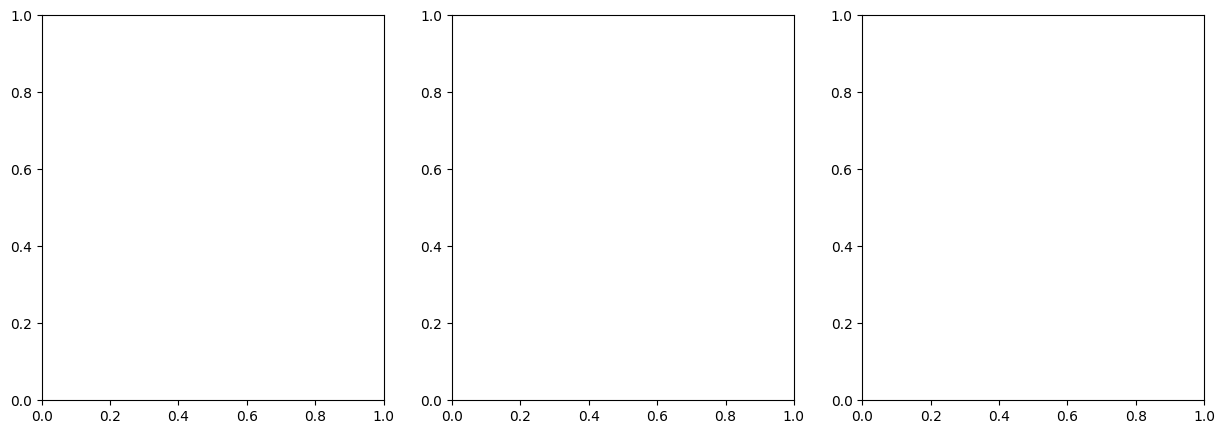

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS = {"Bulk": "#4C72B0", "Rhizosphere": "#55A868", "Nodule": "#C44E52"}
conds = ["Bulk", "Rhizosphere", "Nodule"]
species_name = re.sub(r'\d+', '', model.name.replace("_", " ")).strip()

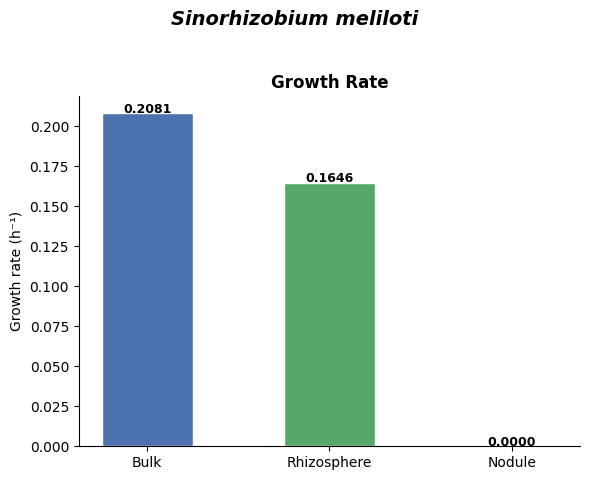

In [26]:
# Plot 1: growth rate bar 
fig1, ax = plt.subplots(figsize=(6, 5))
vals = [summary_df[summary_df.Condition==c]["Growth_rate_h"].values[0]
        if summary_df[summary_df.Condition==c]["Status"].values[0]=="optimal" else 0
        for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Growth rate (h⁻¹)")
ax.set_title("Growth Rate", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
fig1.suptitle(species_name, fontsize=14, fontweight="bold", style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig1.savefig(os.path.join(save_path, "1_growth_rate.png"), dpi=300)
plt.show()

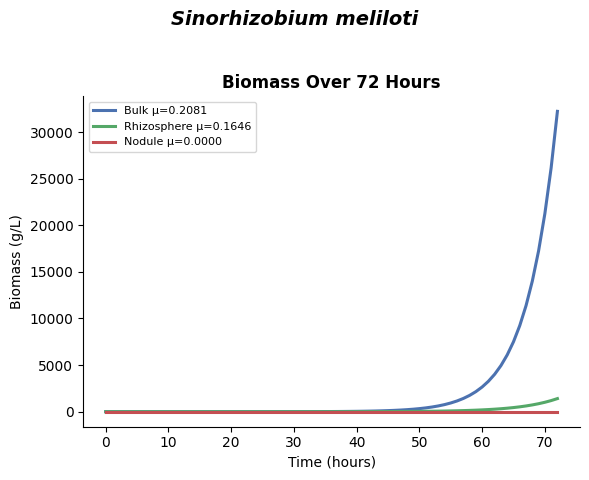

In [27]:
# Plot 2: biomass over time 
fig2, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = time_df[time_df.condition == cond]
    mu = sub["mu"].iloc[0]
    ax.plot(sub.time_h, sub.biomass_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} µ={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Biomass (g/L)")
ax.set_title("Biomass Over 72 Hours", fontweight="bold")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig2.suptitle(species_name, fontsize=14, fontweight="bold", style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.savefig(os.path.join(save_path, "2_biomass_over_time.png"), dpi=300)
plt.show()

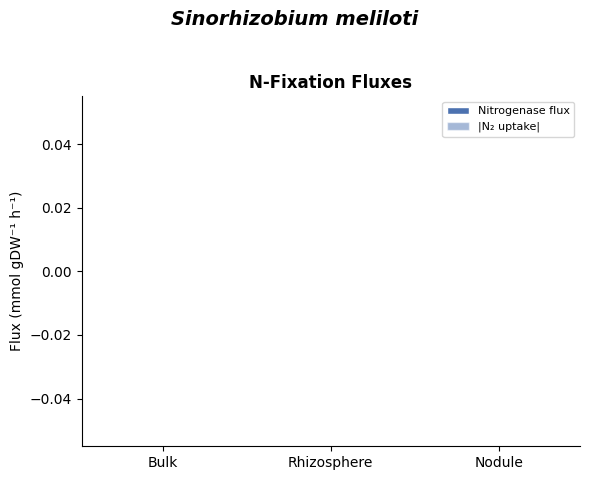

In [28]:
# Plot 3: nitrogenase + N2 uptake 
fig3, ax = plt.subplots(figsize=(6, 5))
nif_vals = summary_df["Nitrogenase_flux"].fillna(0).tolist()
n2_vals = summary_df["N2_uptake"].fillna(0).tolist()
x = np.arange(len(conds))
w = 0.35
ax.bar(x - w/2, nif_vals, width=w, label="Nitrogenase flux", color=[COLORS[c] for c in conds], edgecolor="white")
ax.bar(x + w/2, n2_vals, width=w, label="|N₂ uptake|", color=[COLORS[c] for c in conds], edgecolor="white", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(conds)
ax.set_ylabel("Flux (mmol gDW⁻¹ h⁻¹)")
ax.set_title("N-Fixation Fluxes", fontweight="bold")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig3.suptitle(species_name, fontsize=14, fontweight="bold", style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig3.savefig(os.path.join(save_path, "3_nitrogen_fluxes.png"), dpi=300)
plt.show()


In [29]:
print(f"Files saved in {save_path}:")
print("- 1_growth_rate.png")
print("- 2_biomass_over_time.png")
print("- 3_nitrogen_fluxes.png")

Files saved in Results_S_meliloti_1348:
- 1_growth_rate.png
- 2_biomass_over_time.png
- 3_nitrogen_fluxes.png


find nitrogent fixation reaction

In [30]:
matches = [m for m in model.metabolites if 'n2' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

cpd00030[c0] Mn2_c0
cpd00030[e0] Mn2_e0
cpd00034[c0] Zn2_c0
cpd00034[e0] Zn2_e0
cpd00528[c0] N2_c0
cpd00528[e0] N2 gas_e0
cpd01326[c0] L-Lysyl-tRNA(Lys)_C16H29N2O11PR2(C5H8O6PR)n


In [31]:
# check nitrogen fixation reaction
nif_rxns = ["rxn06874_c0", "rxnNifS_c0", "rxnNifU", "symbiosis_c0",
            "EX_cpd00528_e0", "EX_cpdFixed_e0"]
print("\nNitrogen fixation reactions:")
for rid in nif_rxns:
    try:
        r = model.reactions.get_by_id(rid)
        print(f"{rid:30s} | {r.name}")
    except KeyError:
        print(f"{rid} — NOT FOUND")


Nitrogen fixation reactions:
rxn06874_c0                    | nitrogenase
rxnNifS_c0                     | sulphur atom for Fe–S cluster biogenesis
rxnNifU                        | Iron sulfur cluster assembly
symbiosis_c0                   | Nitrogen fixing symbiosis reaction
EX_cpd00528_e0                 | EX N2 gas e0
EX_cpdFixed_e0                 | Fixed ammonia e0


In [32]:
nitrogenase_id = model.reactions.get_by_id("rxn06874_c0") 
print(nitrogenase_id.reaction)

16.0 cpd00001[c0] + 16.0 cpd00002[c0] + cpd00528[c0] + 4.0 cpd11620[c0] --> 16.0 cpd00008[c0] + 16.0 cpd00009[c0] + 6.0 cpd00067[c0] + 4.0 cpd11621[c0] + cpd11640[c0] + 2.0 cpdFixed[c0]


set environment for fix nitrogen

In [33]:
# no ammonia or nitrate
model.reactions.get_by_id("EX_cpd00013_e0").lower_bound = 0
# acept nitrogen
model.reactions.get_by_id("EX_cpd00528_e0").lower_bound = -10

calculate optimization

how bacteria fix nitrogen to growth 

In [34]:
n2_fixation_id = nitrogenase_id
n2_result_summary = []

for cond_name, sol, model_cond in [
        ("bulk",         solution_bulk, model_bulk),
        ("rhizosphere", solution_rh,   model_rh),
        ("nodule",       solution_no,   model_no),
]:
    if sol.status != "optimal":
        print(f"  {cond_name}: skipped (infeasible)")
        continue

    flux_df = sol.to_frame().reset_index()
    flux_df.columns = ["reaction_id", "flux", "reduced_cost"]

    # find nitrogen fixation 
    if n2_fixation_id in sol.fluxes:
        n2_flux = sol.fluxes[n2_fixation_id]
        n2_result_summary.append({
            "condition": cond_name,
            "n2_fixation_flux": n2_flux,
            "status": sol.status
        })
    else:
        print(f"  Warning: {n2_fixation_id} not found in {cond_name} model")

    flux_df["reaction_name"] = flux_df["reaction_id"].apply(
        lambda rid: model_cond.reactions.get_by_id(rid).name
        if rid in model_cond.reactions else ""
    )
    flux_df.insert(0, "condition", cond_name)

    fname = os.path.join(save_path, f"{cond_name}_fluxes.tsv")
    flux_df.to_csv(fname, sep="\t", index=False)
    print(f"  Saved {cond_name} fluxes with N2 Fixation rate: {n2_flux if n2_fixation_id in sol.fluxes else 'N/A'}")

summary_df = pd.DataFrame(n2_result_summary)
print("\n--- Nitrogen Fixation Summary ---")
print(summary_df)

  Saved bulk fluxes with N2 Fixation rate: N/A
  Saved rhizosphere fluxes with N2 Fixation rate: N/A
  Saved nodule fluxes with N2 Fixation rate: N/A

--- Nitrogen Fixation Summary ---
Empty DataFrame
Columns: []
Index: []


maximum

nitrogen fixation objective == how maximum bacteria can fix nitrogen only

In [35]:
max_n2_results = []
for cond_name, model_orig in [
        ("bulk", model_bulk),
        ("rhizosphere", model_rh),
        ("nodule", model_no),
]:
    for cond_name, model_orig in [
        ("bulk", model_bulk),
        ("rhizosphere", model_rh),
        ("nodule", model_no),
    ]:
        with model_orig as model:
            if n2_fixation_id in model.reactions:
                model.objective = n2_fixation_id
                sol = model.optimize()

                if sol.status == "optimal":
                    max_val = sol.objective_value
                    print(f"{cond_name}: Maximum Nitrogen fixation = {max_val: 4f}")

                    max_n2_results.append({
                        "condition": cond_name,
                        "max_n2_flux": max_val
                    })

                    flux_df = sol.to_frame().reset_index()
                    flux_df.columns = ["reaction_id", "flux", "reduced_cost"]
                    flux_df.insert(0, "condition", f"{cond_name}_max_n2")
                    fname = os.path.join(save_path, f"{cond_name}_max_n2_fluxes.tsv")
                    flux_df.to_csv(fname, sep="\t", index=False)
                else:
                    print(f"  {cond_name}: Infeasible for N2 fixation")
            else:
                print(f"  {cond_name}: Reaction {n2_fixation_id} not found")
        
        print("\n--- Theoretical Maximum N2 Fixation Capacity ---")
print(pd.DataFrame(max_n2_results))

bulk: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
rhizosphere: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
nodule: Maximum Nitrogen fixation = -0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
bulk: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
rhizosphere: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
nodule: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
bulk: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
rhizosphere: Maximum Nitrogen fixation =  0.000000



--- Theoretical Maximum N2 Fixation Capacity ---
nodule: Maximum Nitrogen fixation =  0.000000

--- Theoretical Maximum N2 Fixation Capacity ---
     condition   max_n2_flux
0         bulk  0.000000e+00
1  rhizosphere  0.000000e+00
2       nodule -4.464616e-35
3         bulk  0.000000e+00
4  rhizosphere  0.000000e+00
5       nodule  0.000000e+00
6         bulk  0.000000e+00
7  rhizosphere  0.000000e+00
8       nodule  0.000000e+00


list all save files

In [36]:
import glob
print(f"\nChecking saved files in {save_path}/")
files = sorted(glob.glob(os.path.join(save_path, "*")))
for f in files:
    size = os.path.getsize(f)
    print(f"  {os.path.basename(f):45s} | {size:>10,} bytes")


Checking saved files in Results_S_meliloti_1348/
  1_growth_rate.png                             |     85,075 bytes
  2_biomass_over_time.png                       |    108,875 bytes
  3_nitrogen_fluxes.png                         |     74,314 bytes
  S_meliloti_1348_metabolites_for_mapping.csv   |     63,321 bytes
  S_meliloti_1348_reactions_for_mapping.csv     |    179,071 bytes
  biomass_over_time.tsv                         |      8,950 bytes
  boundary_list.txt                             |      9,454 bytes
  boundary_reactions.csv                        |      8,745 bytes
  boundary_reactions.tsv                        |      8,745 bytes
  bulk_fluxes.tsv                               |    108,141 bytes
  bulk_genes.tsv                                |     58,615 bytes
  bulk_max_n2_fluxes.tsv                        |     56,770 bytes
  exchange_fluxes_all_conditions.tsv            |      5,573 bytes
  growth_rate_summary.tsv                       |        351 bytes
  nodule_flu